# Visualizing Neural Network Decision Boundaries

Neural networks learn to draw boundaries between groups. In this demo, we'll watch that happen — starting from the simplest possible case and working up to patterns that only a neural network can handle.

## Setup

In [1]:
%pip install -q -r requirements.txt

# GPU acceleration (platform-specific)
import platform
if platform.system() == "Darwin" and platform.machine() == "arm64":
    %pip install -q tensorflow-metal

%reset -f

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.config.run_functions_eagerly(True)

# Report available accelerators
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU acceleration: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("No GPU detected — using CPU")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from keras import Sequential
from keras.layers import Dense

np.random.seed(42)

GPU acceleration: 1 device(s)
  /physical_device:GPU:0


## Helper functions

We'll reuse these throughout the demo. `plot_decision_boundary` is the workhorse — it creates a fine grid over the input space, asks the model to classify every point, and colors the regions.

In [3]:
def plot_decision_boundary(model, X, y, title=None, ax=None):
    """Plot data points and the model's decision boundary."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # Create a grid of points covering the data range
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict on every grid point (direct call avoids model.predict overhead)
    preds = model(grid, training=False).numpy().reshape(xx.shape)

    # Color the regions
    ax.contourf(xx, yy, preds, levels=[0, 0.5, 1], alpha=0.3,
                colors=['#4477AA', '#EE7733'])
    ax.contour(xx, yy, preds, levels=[0.5], colors='k', linewidths=1)

    # Plot the data points
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='#4477AA', edgecolors='k',
               s=30, label='Class 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='#EE7733', edgecolors='k',
               s=30, label='Class 1')

    if title:
        ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    return ax


def build_and_train(X, y, hidden_layers=None, epochs=100, verbose=0):
    """Build a Sequential model, train it, return the model.

    hidden_layers: list of ints, e.g. [8] or [16, 8].
                   None or [] means no hidden layer (single neuron).
    """
    from keras.optimizers import Adam

    layers = []
    if hidden_layers:
        for i, units in enumerate(hidden_layers):
            if i == 0:
                layers.append(Dense(units, activation='relu', input_shape=(2,)))
            else:
                layers.append(Dense(units, activation='relu'))
    # Output neuron — sigmoid for binary classification
    if not layers:
        layers.append(Dense(1, activation='sigmoid', input_shape=(2,)))
    else:
        layers.append(Dense(1, activation='sigmoid'))

    model = Sequential(layers)
    model.compile(optimizer=Adam(learning_rate=0.1), loss='binary_crossentropy',
                  metrics=['accuracy'])
    model.fit(X, y, epochs=epochs, batch_size=len(X), verbose=verbose)
    return model

---

## Example 1: Vertical split

The simplest possible classification — two clusters separated by a vertical line at x=0. A single neuron (logistic regression) can draw this boundary with one weight.

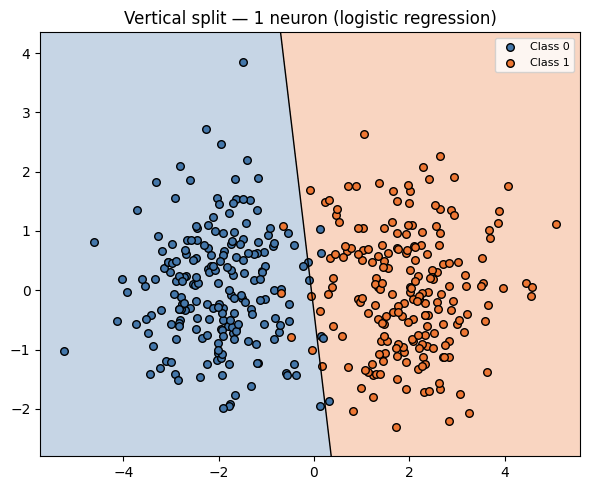

In [4]:
# Generate two clusters split left/right
n = 200
X1 = np.random.randn(n, 2) + np.array([-2, 0])
X1_labels = np.zeros(n)
X2 = np.random.randn(n, 2) + np.array([2, 0])
X2_labels = np.ones(n)

X_vert = np.vstack([X1, X2])
y_vert = np.hstack([X1_labels, X2_labels])

# Single neuron — this is logistic regression
model = build_and_train(X_vert, y_vert)
plot_decision_boundary(model, X_vert, y_vert,
                       title='Vertical split — 1 neuron (logistic regression)')
plt.tight_layout()
plt.show()

One neuron, one weight that matters, a straight vertical boundary. This is exactly logistic regression from last lecture — just written in Keras.

---

## Example 2: Diagonal split

Now both features matter. The boundary is a diagonal line — the neuron needs to combine both inputs with non-trivial weights.

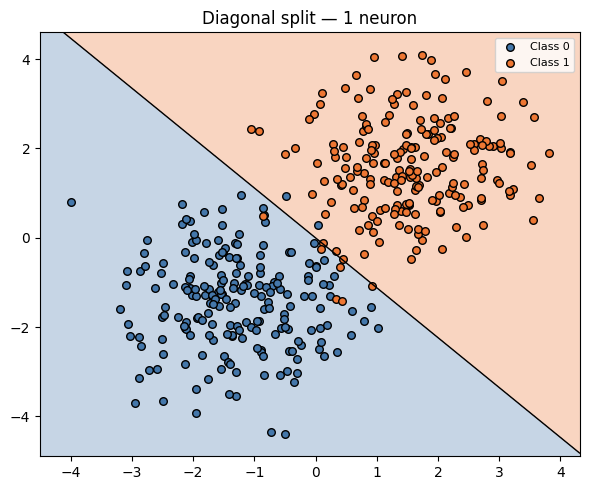

In [5]:
# Generate two clusters split along a diagonal
angle = np.pi / 4  # 45 degrees
X1 = np.random.randn(n, 2) + np.array([-1.5, -1.5])
X2 = np.random.randn(n, 2) + np.array([1.5, 1.5])
X_diag = np.vstack([X1, X2])
y_diag = np.hstack([np.zeros(n), np.ones(n)])

model = build_and_train(X_diag, y_diag)
plot_decision_boundary(model, X_diag, y_diag,
                       title='Diagonal split — 1 neuron')
plt.tight_layout()
plt.show()

Still a straight line, but now tilted. The weights on both inputs are doing work. A single neuron can draw any straight-line boundary — but only straight lines.

---

## Example 3: Moons

Two interleaving crescents. No straight line can separate them. This is where we need a hidden layer.

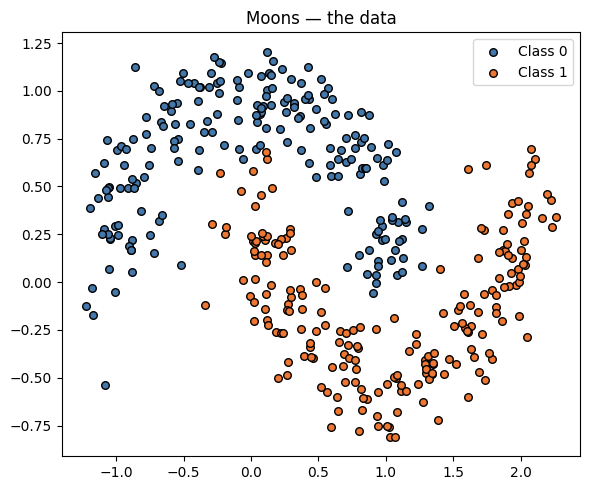

In [6]:
X_moon, y_moon = make_moons(n_samples=400, noise=0.15, random_state=42)

# Show the data first
plt.figure(figsize=(6, 5))
plt.scatter(X_moon[y_moon == 0, 0], X_moon[y_moon == 0, 1],
            c='#4477AA', edgecolors='k', s=30, label='Class 0')
plt.scatter(X_moon[y_moon == 1, 0], X_moon[y_moon == 1, 1],
            c='#EE7733', edgecolors='k', s=30, label='Class 1')
plt.title('Moons — the data')
plt.legend()
plt.tight_layout()
plt.show()

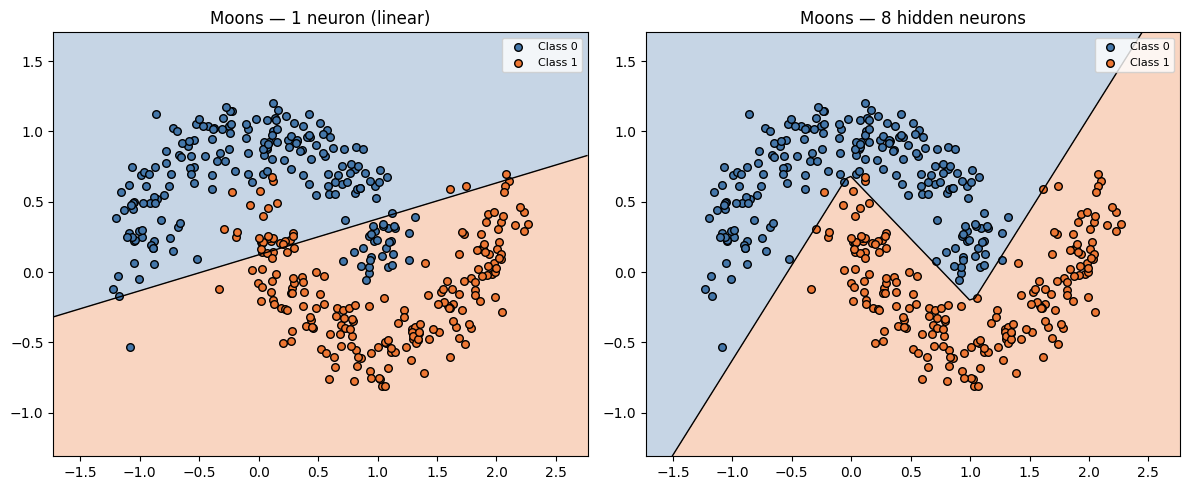

In [7]:
# Try a single neuron first — it will fail
model_1 = build_and_train(X_moon, y_moon)
# Then add a hidden layer with 8 neurons
model_8 = build_and_train(X_moon, y_moon, hidden_layers=[8])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(model_1, X_moon, y_moon,
                       title='Moons — 1 neuron (linear)', ax=axes[0])
plot_decision_boundary(model_8, X_moon, y_moon,
                       title='Moons — 8 hidden neurons', ax=axes[1])
plt.tight_layout()
plt.show()

The single neuron draws the best straight line it can — but it's wrong on a lot of points. Eight hidden neurons with ReLU activation can bend the boundary around the crescents.

---

## Example 4: Circles

One group surrounded by another. The boundary needs to be a closed curve — no straight line, no matter how you tilt it, can separate an inner ring from an outer ring.

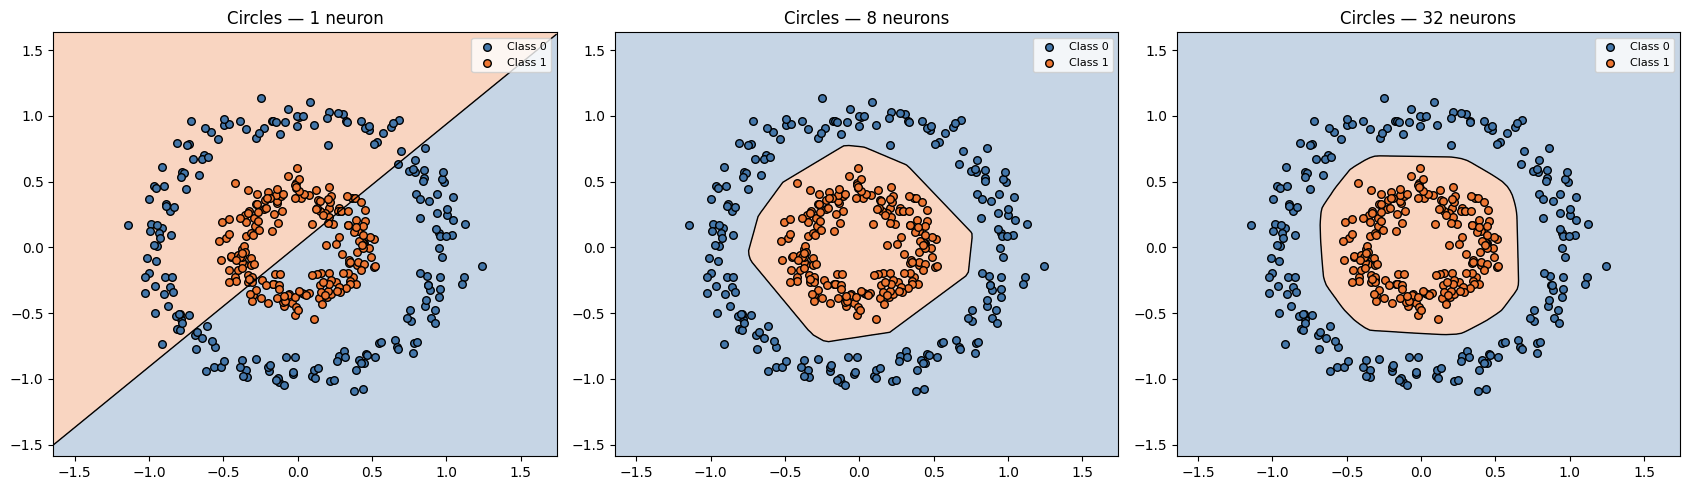

In [8]:
X_circ, y_circ = make_circles(n_samples=400, noise=0.08, factor=0.4,
                               random_state=42)

model_1 = build_and_train(X_circ, y_circ)
model_8 = build_and_train(X_circ, y_circ, hidden_layers=[8])
model_32 = build_and_train(X_circ, y_circ, hidden_layers=[32])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
plot_decision_boundary(model_1, X_circ, y_circ,
                       title='Circles — 1 neuron', ax=axes[0])
plot_decision_boundary(model_8, X_circ, y_circ,
                       title='Circles — 8 neurons', ax=axes[1])
plot_decision_boundary(model_32, X_circ, y_circ,
                       title='Circles — 32 neurons', ax=axes[2])
plt.tight_layout()
plt.show()

Watch the boundary close around the inner ring as we add neurons. This is the Universal Approximation Theorem in action — given enough neurons, the network can learn any shape.

---

## Example 5: XOR pattern

Four clusters, but the classes criss-cross — class 0 in the top-left and bottom-right, class 1 in the top-right and bottom-left. The network has to learn two separate regions for each class.

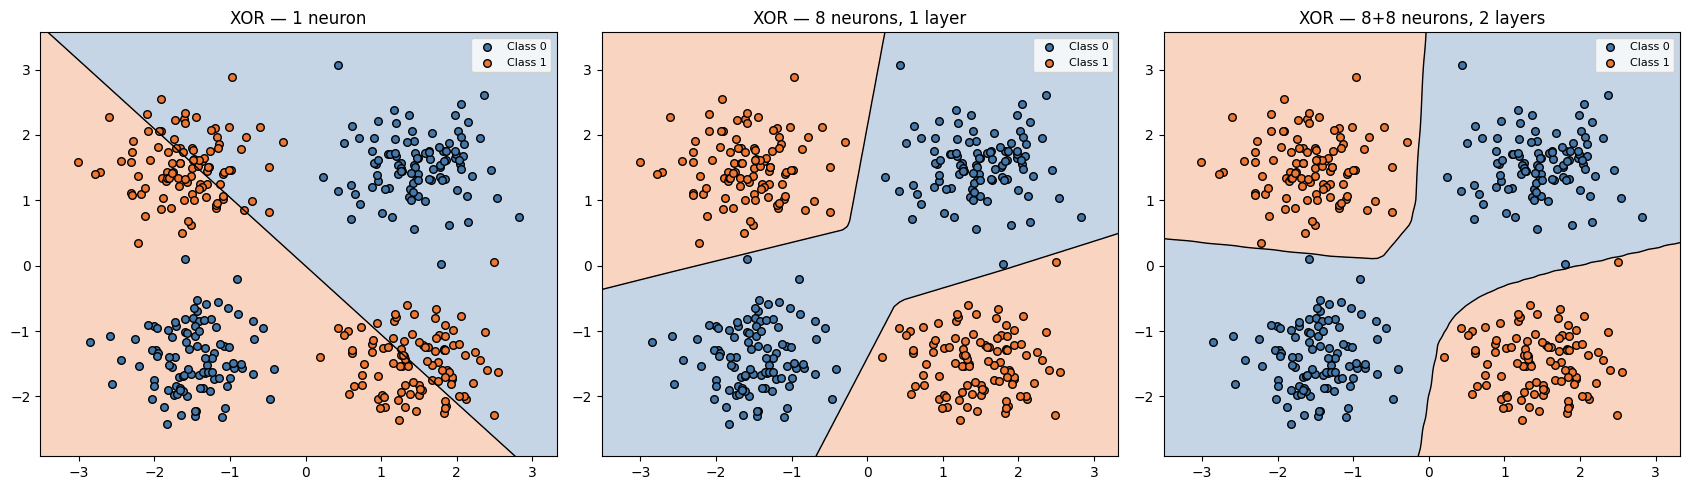

In [9]:
# XOR-like arrangement
c1 = np.random.randn(100, 2) * 0.5 + np.array([-1.5, -1.5])
c2 = np.random.randn(100, 2) * 0.5 + np.array([1.5, 1.5])
c3 = np.random.randn(100, 2) * 0.5 + np.array([-1.5, 1.5])
c4 = np.random.randn(100, 2) * 0.5 + np.array([1.5, -1.5])

X_xor = np.vstack([c1, c2, c3, c4])
y_xor = np.hstack([np.zeros(100), np.zeros(100),
                    np.ones(100), np.ones(100)])

model_1 = build_and_train(X_xor, y_xor)
model_8 = build_and_train(X_xor, y_xor, hidden_layers=[8])
model_deep = build_and_train(X_xor, y_xor, hidden_layers=[8, 8])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
plot_decision_boundary(model_1, X_xor, y_xor,
                       title='XOR — 1 neuron', ax=axes[0])
plot_decision_boundary(model_8, X_xor, y_xor,
                       title='XOR — 8 neurons, 1 layer', ax=axes[1])
plot_decision_boundary(model_deep, X_xor, y_xor,
                       title='XOR — 8+8 neurons, 2 layers', ax=axes[2])
plt.tight_layout()
plt.show()

XOR is famously impossible for a single neuron — this was a major insight in neural network history (Minsky & Papert, 1969). Adding a hidden layer solves it. The two-layer version creates cleaner, more separated regions.

---

## Example 6: Spirals

Two interleaving spirals — the hardest pattern. Each class wraps around the other. This needs a deeper network to trace the winding boundary.

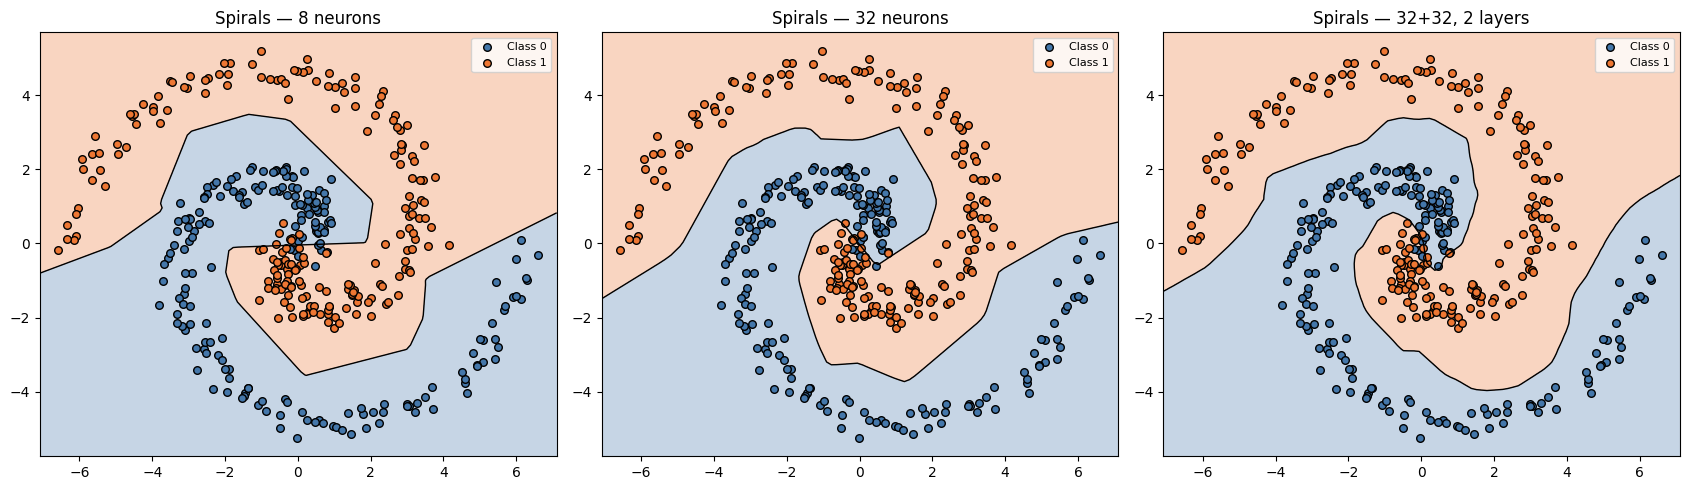

In [10]:
# Generate two spirals
def make_spirals(n_points=200, noise=0.3):
    t = np.linspace(0, 2 * np.pi, n_points)
    # Spiral 1
    x1 = t * np.cos(t) + np.random.randn(n_points) * noise
    y1 = t * np.sin(t) + np.random.randn(n_points) * noise
    # Spiral 2 (rotated 180 degrees)
    x2 = t * np.cos(t + np.pi) + np.random.randn(n_points) * noise
    y2 = t * np.sin(t + np.pi) + np.random.randn(n_points) * noise

    X = np.vstack([np.column_stack([x1, y1]),
                   np.column_stack([x2, y2])])
    y = np.hstack([np.zeros(n_points), np.ones(n_points)])
    return X, y

X_spiral, y_spiral = make_spirals()

model_8 = build_and_train(X_spiral, y_spiral, hidden_layers=[8], epochs=100)
model_32 = build_and_train(X_spiral, y_spiral, hidden_layers=[32], epochs=100)
model_deep = build_and_train(X_spiral, y_spiral, hidden_layers=[32, 32],
                              epochs=100)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
plot_decision_boundary(model_8, X_spiral, y_spiral,
                       title='Spirals — 8 neurons', ax=axes[0])
plot_decision_boundary(model_32, X_spiral, y_spiral,
                       title='Spirals — 32 neurons', ax=axes[1])
plot_decision_boundary(model_deep, X_spiral, y_spiral,
                       title='Spirals — 32+32, 2 layers', ax=axes[2])
plt.tight_layout()
plt.show()

The shallow models struggle to trace the winding path. The deeper network does better — this connects to the lecture point that deeper networks with fewer neurons per layer tend to generalize better than very wide, shallow networks.

---

## What the hidden neurons actually see

Each hidden neuron with 2 inputs has 2 weights and 1 bias — that defines a line in 2D. The ReLU activation means the neuron "fires" on one side of that line and is silent on the other. The output layer combines these half-planes into the full decision boundary.

Let's look inside the 8-neuron moons model:

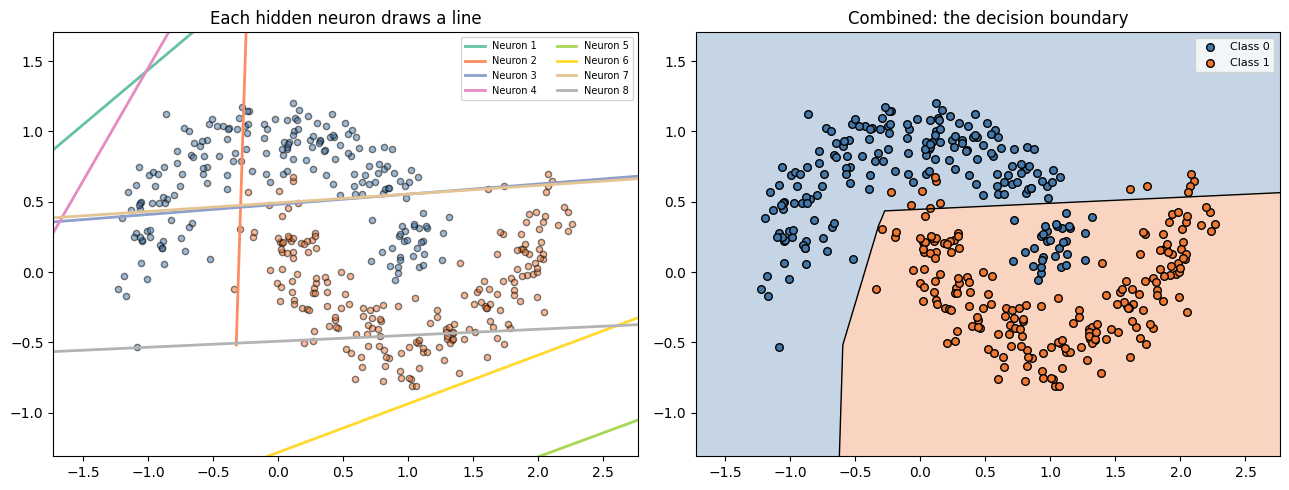

In [11]:
# Get the weights from the hidden layer of the moons model
model_viz = build_and_train(X_moon, y_moon, hidden_layers=[8])
weights, biases = model_viz.layers[0].get_weights()

# Each column of weights defines a line: w0*x + w1*y + b = 0
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: the lines each neuron draws
ax = axes[0]
ax.scatter(X_moon[y_moon == 0, 0], X_moon[y_moon == 0, 1],
           c='#4477AA', edgecolors='k', s=20, alpha=0.5)
ax.scatter(X_moon[y_moon == 1, 0], X_moon[y_moon == 1, 1],
           c='#EE7733', edgecolors='k', s=20, alpha=0.5)

x_range = np.linspace(X_moon[:, 0].min() - 0.5, X_moon[:, 0].max() + 0.5, 100)
colors = plt.cm.Set2(np.linspace(0, 1, 8))
for i in range(weights.shape[1]):
    w0, w1 = weights[:, i]
    b = biases[i]
    if abs(w1) > 1e-6:
        # Line: w0*x + w1*y + b = 0 => y = -(w0*x + b) / w1
        y_line = -(w0 * x_range + b) / w1
        mask = (y_line > X_moon[:, 1].min() - 1) & (y_line < X_moon[:, 1].max() + 1)
        ax.plot(x_range[mask], y_line[mask], color=colors[i],
                linewidth=2, label=f'Neuron {i+1}')
ax.set_title('Each hidden neuron draws a line')
ax.legend(fontsize=7, ncol=2)
ax.set_xlim(X_moon[:, 0].min() - 0.5, X_moon[:, 0].max() + 0.5)
ax.set_ylim(X_moon[:, 1].min() - 0.5, X_moon[:, 1].max() + 0.5)

# Right: the combined decision boundary
plot_decision_boundary(model_viz, X_moon, y_moon,
                       title='Combined: the decision boundary', ax=axes[1])

plt.tight_layout()
plt.show()

Each neuron contributes one straight cut. The output layer learns how to combine those cuts — adding, weighting, and thresholding — to produce the curved boundary you see on the right. More neurons means more cuts to work with, which means more complex shapes.